In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
# ============================================================
# DISEASE PREDICTION FROM MEDICAL DATA
# VertexMind Internship - Task 4
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load Breast Cancer Dataset

data = load_breast_cancer()

# Create DataFrame

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add target column

df['target'] = data.target

print("Dataset Loaded Successfully")

# Display first 5 rows

df.head()

Dataset Loaded Successfully


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\n================================")

print("Target Distribution:")

print(df['target'].value_counts())

print("\n================================")

print("Missing Values:")

print(df.isnull().sum())

Dataset Shape:
(569, 31)

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target         

In [5]:
# Split features and target

X = df.drop('target', axis=1)

y = df['target']

print("Features and Target Split Successfully")

Features and Target Split Successfully


In [6]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [7]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed



Logistic Regression
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
ROC AUC   : 0.9954

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



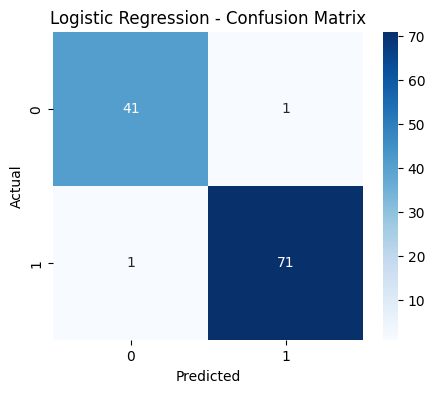

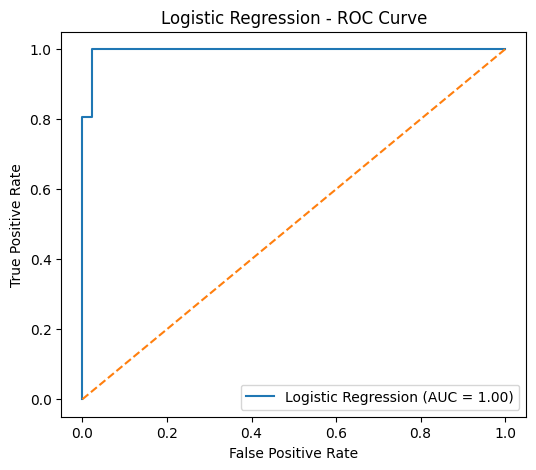


Support Vector Machine
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
ROC AUC   : 0.9950

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



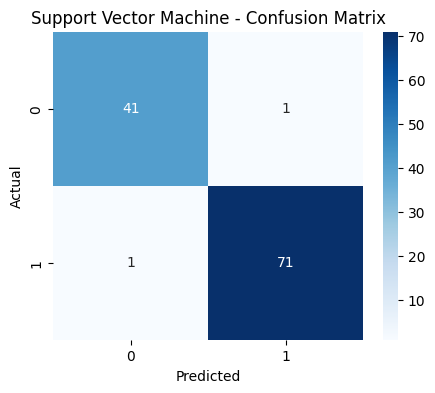

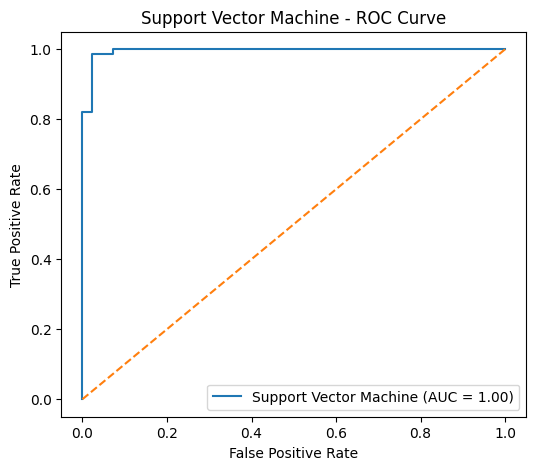


Random Forest
Accuracy  : 0.9561
Precision : 0.9589
Recall    : 0.9722
F1 Score  : 0.9655
ROC AUC   : 0.9939

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



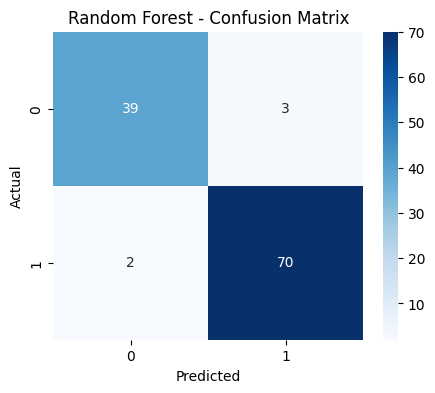

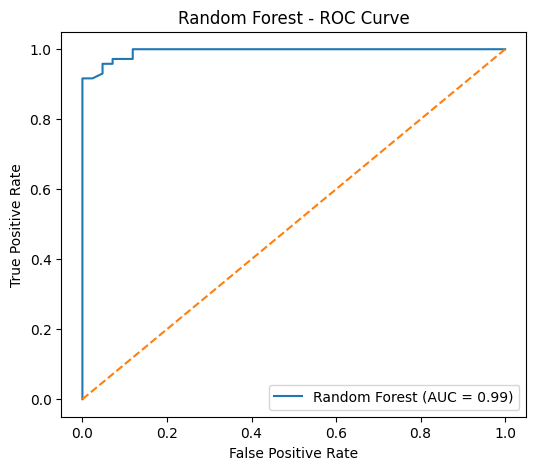

In [8]:
# ============================================================
# TRAIN MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    print("\n================================================")
    print(name)
    print("================================================")

    # Train model

    model.fit(X_train_scaled, y_train)

    # Predictions

    y_pred = model.predict(X_test_scaled)

    # Probability predictions

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = roc_auc

    # Print metrics

    print(f"Accuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc_auc:.4f}")

    # Classification Report

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} - Confusion Matrix')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

    # ============================================================
    # ROC CURVE
    # ============================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.2f})'
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title(f'{name} - ROC Curve')

    plt.legend()

    plt.show()

In [9]:
# ============================================================
# BEST MODEL
# ============================================================

best_model = max(results, key=results.get)

print("================================")

print("Best Performing Model")

print("================================")

print(f"\nModel Name: {best_model}")

print(f"\nROC AUC Score: {results[best_model]:.4f}")

Best Performing Model

Model Name: Logistic Regression

ROC AUC Score: 0.9954


In [10]:
# ============================================================
# DISEASE PREDICTION SYSTEM
# ============================================================

# Train Random Forest Model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

print("========================================")
print(" DISEASE PREDICTION SYSTEM ")
print("========================================")

# ============================================================
# SAMPLE INPUT VALUES
# ============================================================

# Healthy Example:
#
# mean radius = 12
# mean texture = 14
# mean perimeter = 78
# mean area = 450
#
# Expected Output:
# LOW DISEASE RISK

# Disease Example:
#
# mean radius = 20
# mean texture = 30
# mean perimeter = 130
# mean area = 1200
#
# Expected Output:
# HIGH DISEASE RISK

# ============================================================

# Take first 4 important features as input

inputs = []

for feature in data.feature_names[:4]:

    value = float(input(f"Enter {feature}: "))

    inputs.append(value)

# Fill remaining features with mean values

remaining = list(X.mean()[4:])

final_input = np.array([inputs + remaining])

# Scale input

final_input_scaled = scaler.transform(final_input)

# Prediction

prediction = rf_model.predict(final_input_scaled)

probability = rf_model.predict_proba(final_input_scaled).max()

# ============================================================
# FINAL RESULT
# ============================================================

print("\n========================================")
print(" DISEASE PREDICTION RESULT ")
print("========================================")

if prediction[0] == 1:

    print("\nPrediction : LOW DISEASE RISK")

    print(f"Confidence Score : {probability:.2f}")

    print("\nMedical Status : HEALTHY")

else:

    print("\nPrediction : HIGH DISEASE RISK")

    print(f"Confidence Score : {probability:.2f}")

    print("\nMedical Status : CONSULT DOCTOR")

print("\n========================================")

 DISEASE PREDICTION SYSTEM 

 DISEASE PREDICTION RESULT 

Prediction : HIGH DISEASE RISK
Confidence Score : 0.62

Medical Status : CONSULT DOCTOR



In [11]:
# ============================================================
# HEALTHCARE IMPACT ANALYSIS
# ============================================================

print("""
Healthcare Impact of Disease Prediction System
----------------------------------------------

1. Early Disease Detection
   Helps doctors identify diseases at an early stage.

2. Faster Medical Decisions
   Assists healthcare professionals with AI-based predictions.

3. Reduced Diagnostic Errors
   Machine learning models improve prediction consistency.

4. Cost Effective Healthcare
   Early prediction reduces expensive treatments later.

5. Better Patient Monitoring
   High-risk patients can be monitored continuously.
""")


Healthcare Impact of Disease Prediction System
----------------------------------------------

1. Early Disease Detection
   Helps doctors identify diseases at an early stage.

2. Faster Medical Decisions
   Assists healthcare professionals with AI-based predictions.

3. Reduced Diagnostic Errors
   Machine learning models improve prediction consistency.

4. Cost Effective Healthcare
   Early prediction reduces expensive treatments later.

5. Better Patient Monitoring
   High-risk patients can be monitored continuously.

